# TerraMind on the EuroCrops pilot chips, explained

This notebook walks through the Phase 1 segmentation pipeline one step at a time, on the Estonian 2021 pilot chips:

1. **The chips on disk.** What one training example is, and how its 144 bands are laid out.
2. **From file to tensor.** How TerraTorch reads a chip, and how normalisation works.
3. **Looking at the data.** Imagery across the season, the labels, and the phenology the model has to learn.
4. **The label budget.** How *K polygons per class* becomes a sparse training mask.
5. **The model.** A frozen TerraMind encoder, the temporal wrapper, the neck, the UNet decoder, with tensor shapes at every stage.
6. **Training.** Load the checkpoint written by the script, or train here.
7. **Results.** Learning curves, prediction maps, per-class scores, and what they do and do not say.

**Before running.** Select the kernel **Python 3.11 (gfm4agri)**. The pilot chips must exist in `data/eurocrops_chips/EE_2021_pilot`; build them with `scripts/data/build_pilot_chips.py`. If no checkpoint is found, section 6 trains one here, which takes about 5 minutes on the A4000. The notebook uses the same builders as `scripts/seg/train.py`, so what you inspect here is exactly what the script trains.

**What this is not.** A pipeline test. The pilot has 8 training and 4 validation chips, no spatial block split and no test chips, so every score below is on the validation chips and is not a thesis result.

In [1]:
import json, sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import yaml

REPO = Path.cwd().resolve()
while not (REPO / "pyproject.toml").exists():
    REPO = REPO.parent
sys.path.insert(0, str(REPO / "src"))

from gfm4agri.benchmark.backbones import get_backbone
from gfm4agri.benchmark.segmentation import build_task, count_params
from gfm4agri.benchmark.segmentation_data import EuroCropsSegDataModule, draw_support

CONFIG = REPO / "configs/seg/terramind_v1_large_ee_pilot.yaml"
cfg = yaml.safe_load(CONFIG.read_text())
ROOT = REPO / cfg["data"]["root"]
RUN_DIR = REPO / cfg["output_root"] / cfg["run_name"] / f"P100_draw0_seed{cfg['seed']}"
CKPT = RUN_DIR / "checkpoints" / "best-loss.ckpt"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(yaml.safe_dump(cfg, sort_keys=False))
print("checkpoint present:", CKPT.exists(), "| device:", DEVICE)

/home/jovyan/.cache/pypoetry/virtualenvs/gfm4agri-7U2rqC_9-py3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


run_name: terramind_v1_small_ee_pilot
seed: 0
data:
  root: data/eurocrops_chips/EE_2021_pilot
  normalisation: backbone
  batch_size: 4
  num_workers: 4
  augment: true
label_budget:
  mode: dense
  K: 5
  draw_seed: 0
model:
  backbone: terramind_v1_small
  lr: 0.0001
  weight_decay: 0.05
  head_dropout: 0.1
  loss: ce
trainer:
  max_epochs: 40
  precision: 16-mixed
  log_every_n_steps: 1
output_root: results/seg

checkpoint present: True | device: cuda


## 1. The chips on disk

A chip is a 224 x 224 pixel square at 10 m, so 2.24 km on a side, on a fixed grid in EPSG:3035. Every chip has three files:

| file | content |
|---|---|
| `<chip>_merged.tif` | int16, **144 bands** = 12 monthly composites x 12 Sentinel-2 L2A bands, reflectance x 10000 |
| `<chip>.mask.tif` | int16, the crop class of every pixel inside a parcel (0 to 19), **-1** everywhere else |
| `<chip>.parcels.tif` | int32, the EuroCrops parcel id under every pixel, 0 outside parcels |

The mask is the **dense** label, used for evaluation. The parcel raster is what makes label budgets possible without re-exporting anything (section 4).

`manifest.json` records everything a run needs: the classes, band order, per-chip provenance, and the training-chip statistics.

In [2]:
manifest = json.loads((ROOT / "manifest.json").read_text())
print(manifest["dataset"], "|", manifest["purpose"])
print("band layout:", manifest["imagery"]["layout"])
print("units:      ", manifest["imagery"]["units"])
print("composite:  ", manifest["imagery"]["composite"])
chips = pd.DataFrame([{k: c[k] for k in ("chip_id", "split", "labelled_share", "n_parcels")}
                      | {"n_classes": len(c["pixels_per_class"])} for c in manifest["chips"]])
chips

eurocrops_s2_seg_EE_2021_pilot | pipeline test set for the TerraTorch connection; not a Phase 1 split
band layout: (time channels): band index = month_index * 12 + band_index
units:       surface reflectance x 10000, BOA offset removed (DN / 10000 convention)
composite:   per-pixel monthly median of SCL-clear acquisitions, gaps filled by linear interpolation across months


,chip_id,split,labelled_share,n_parcels,n_classes
0,EE_02354_01821,train,0.8045,46,12
1,EE_02329_01782,train,0.7781,53,14
2,EE_02373_01780,val,0.6488,76,14
3,EE_02299_01803,train,0.6343,67,16
4,EE_02346_01825,train,0.8220,64,13
5,EE_02383_01794,val,0.7137,76,15
6,EE_02363_01794,train,0.6241,76,14
7,EE_02340_01843,train,0.7421,56,14
8,EE_02338_01809,val,0.7371,58,13
9,EE_02304_01818,train,0.5545,115,15


The 144 bands are stored **month by month**: bands 1 to 12 are January's 12 bands, 13 to 24 February's, and so on. TerraTorch calls this the `(time channels)` layout, and `expand_temporal_dimension=True` reshapes it back into bands x months. The band descriptions in the GeoTIFF confirm the order:

In [3]:
import rasterio
cid = manifest["chips"][0]["chip_id"]
with rasterio.open(ROOT / "training_chips" / f"{cid}_merged.tif") as src:
    desc = src.descriptions
    print(src.count, "bands,", src.dtypes[0], src.crs, src.res)
print(desc[:13], "...", desc[-2:])

144 bands, int16 EPSG:3035 (10.0, 10.0)
('M01_COASTAL_AEROSOL', 'M01_BLUE', 'M01_GREEN', 'M01_RED', 'M01_RED_EDGE_1', 'M01_RED_EDGE_2', 'M01_RED_EDGE_3', 'M01_NIR_BROAD', 'M01_NIR_NARROW', 'M01_WATER_VAPOR', 'M01_SWIR_1', 'M01_SWIR_2', 'M02_COASTAL_AEROSOL') ... ('M12_SWIR_1', 'M12_SWIR_2')


Winter months in the Baltic are mostly cloud or snow. Pixels with no clear observation in a month are filled by linear interpolation from neighbouring months, and the manifest records how much of each month was filled. **January, October to December are largely interpolated rather than observed.** Keep this in mind when any later explanation attributes importance to those months.

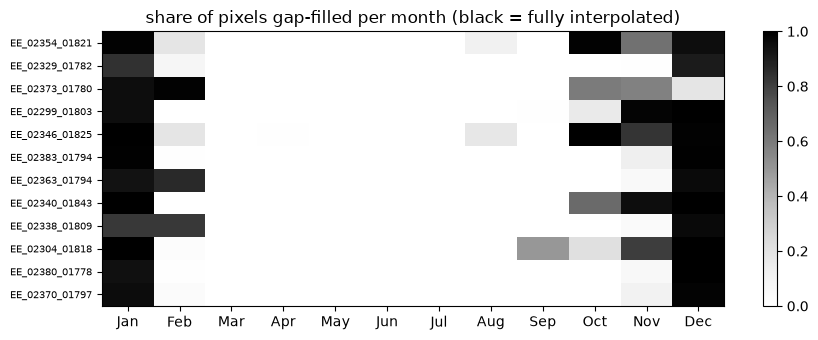

In [4]:
filled = pd.DataFrame([c["imagery"]["filled_share_per_month"] for c in manifest["chips"]],
                      index=[c["chip_id"] for c in manifest["chips"]],
                      columns="Jan Feb Mar Apr May Jun Jul Aug Sep Oct Nov Dec".split())
fig, ax = plt.subplots(figsize=(9, 3.5))
im = ax.imshow(filled.values, cmap="Greys", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(12), filled.columns); ax.set_yticks(range(len(filled)), filled.index, fontsize=7)
ax.set_title("share of pixels gap-filled per month (black = fully interpolated)")
plt.colorbar(im, ax=ax); plt.tight_layout()

## 2. From file to tensor

`EuroCropsSegDataModule` is TerraTorch's `GenericNonGeoSegmentationDataModule` configured from the manifest. Per sample it:

1. reads the 144-band GeoTIFF and reshapes it to `(months, H, W, bands)`;
2. reads the mask, with -1 as the ignore index, which the loss and every metric skip;
3. for training only, applies a random **D4 symmetry** (one of 8 rotations and flips), identical for image and mask;
4. returns the image as a tensor of shape **(bands, months, H, W) = (12, 12, 224, 224)**.

Normalisation is **not** applied per sample. It is applied to the whole batch on the GPU (`dm.aug`), so the dataset returns raw reflectance, which is convenient for plotting.

In [5]:
d = cfg["data"]
dm = EuroCropsSegDataModule(ROOT, cfg["model"]["backbone"], normalisation=d["normalisation"],
                            batch_size=d["batch_size"], num_workers=0, augment=False)
dm.setup("fit")
NAMES = dm.class_names
s = dm.train_dataset[0]
print("image", tuple(s["image"].shape), s["image"].dtype, "| mask", tuple(s["mask"].shape), s["mask"].dtype)
print("mask values:", sorted(s["mask"].unique().tolist()))
print(len(dm.train_dataset), "train chips,", len(dm.val_dataset), "val chips,", len(NAMES), "classes")

/home/jovyan/.cache/pypoetry/virtualenvs/gfm4agri-7U2rqC_9-py3.11/lib/python3.11/site-packages/terratorch/datasets/generic_pixel_wise_dataset.py:131: UserWarning: expand_temporal_dimension=True assumes bands are grouped by time (all bands of one timestep are stacked together). If instead bands are grouped by channel (all timesteps of one band are stacked together), set temporal_channel_major=True.
  warnings.warn(
/home/jovyan/.cache/pypoetry/virtualenvs/gfm4agri-7U2rqC_9-py3.11/lib/python3.11/site-packages/terratorch/datasets/generic_pixel_wise_dataset.py:131: UserWarning: expand_temporal_dimension=True assumes bands are grouped by time (all bands of one timestep are stacked together). If instead bands are grouped by channel (all timesteps of one band are stacked together), set temporal_channel_major=True.
  warnings.warn(


image (12, 12, 224, 224) torch.float32 | mask (224, 224) torch.int64
mask values: [-1, 0, 1, 2, 3, 5, 6, 7, 8, 9, 11, 12, 13, 16, 17, 18, 19]
8 train chips, 4 val chips, 20 classes


**Normalisation.** A frozen encoder only understands inputs on the scale it was pretrained on, so the default (`normalisation: backbone`) standardises each band with **TerraMind's own S2L2A pretraining mean and standard deviation**, read from TerraTorch rather than copied. The alternative (`normalisation: chips`) uses our training-chip statistics.

The table compares the two. Our chips are darker than TerraMind's pretraining data in every band. Part of that is Baltic land cover, and part is probably the +1000 L2A offset carried by post-2022 scenes in the pretraining archive, which our 2021 scenes do not have. After normalisation our data sits a few tenths of a standard deviation below TerraMind's mean. That is within distribution, but it is worth one comparison run with `normalisation: chips`.

In [6]:
tm_mean, tm_std = get_backbone("terramind_v1_large").stats(dm.bands)
stats = pd.DataFrame({"TerraMind mean": tm_mean, "chips mean": manifest["normalisation"]["means"],
                      "TerraMind std": tm_std, "chips std": manifest["normalisation"]["stds"]},
                     index=dm.bands).round(0)
batch = next(iter(dm.train_dataloader()))
x = dm.aug(batch)["image"]
stats["normalised mean"] = x.mean((0, 2, 3, 4)).numpy().round(2)
stats["normalised std"] = x.std((0, 2, 3, 4)).numpy().round(2)
stats

,TerraMind mean,chips mean,TerraMind std,chips std,normalised mean,normalised std
COASTAL_AEROSOL,1390.0,637.0,2107.0,619.0,-0.36,0.26
BLUE,1503.0,696.0,2141.0,550.0,-0.37,0.22
GREEN,1718.0,892.0,2039.0,459.0,-0.40,0.21
RED,1854.0,931.0,2134.0,520.0,-0.43,0.24
RED_EDGE_1,2199.0,1374.0,2085.0,506.0,-0.40,0.24
RED_EDGE_2,2780.0,2218.0,1890.0,841.0,-0.30,0.44
RED_EDGE_3,2987.0,2498.0,1820.0,1009.0,-0.27,0.56
NIR_BROAD,3083.0,2677.0,1872.0,1034.0,-0.22,0.56
NIR_NARROW,3132.0,2725.0,1754.0,1041.0,-0.23,0.61
WATER_VAPOR,3163.0,2808.0,1797.0,992.0,-0.20,0.57


## 3. Looking at the data

Four months of one training chip in true colour, and its labels. White in the label map is ignore: roads, forest, buildings and parcels outside the 20-class scheme.

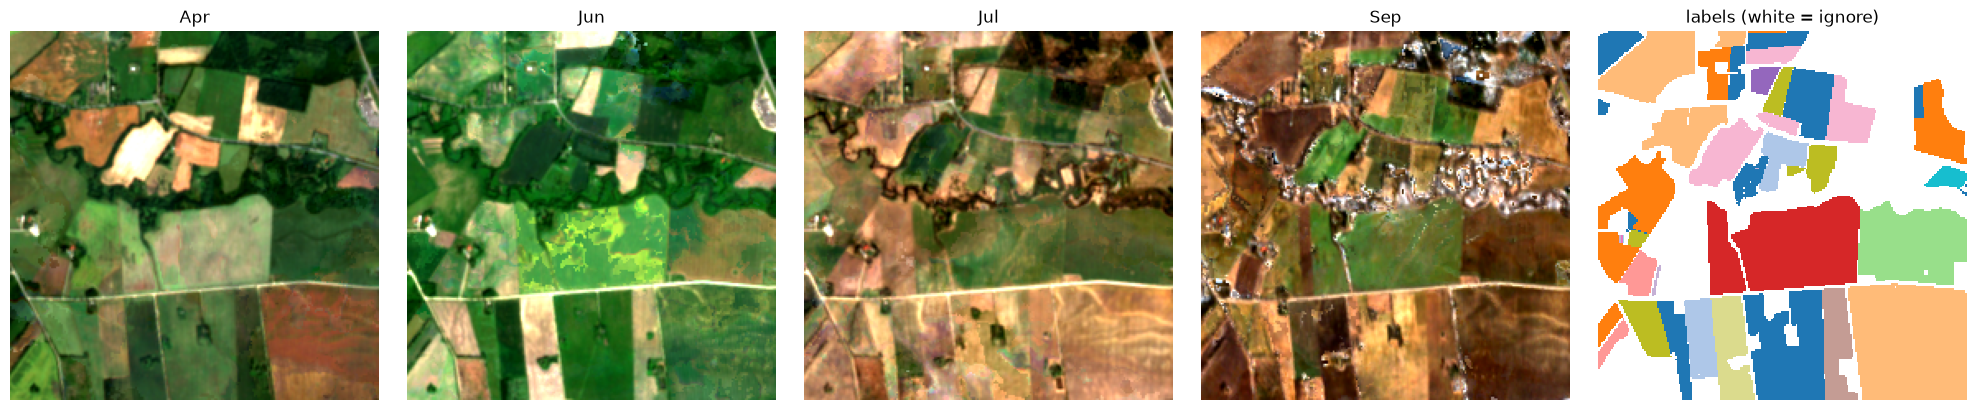

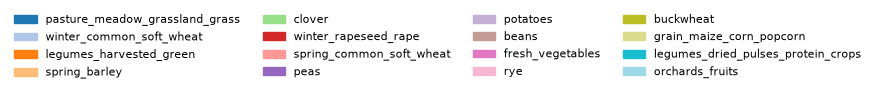

In [7]:
MONTHS = "Jan Feb Mar Apr May Jun Jul Aug Sep Oct Nov Dec".split()
cmap = plt.get_cmap("tab20", len(NAMES))

def rgb(image, month):
    """(C, T, H, W) raw reflectance -> (H, W, 3) with a 2-98 % stretch."""
    b = [dm.bands.index(k) for k in ("RED", "GREEN", "BLUE")]
    a = image[b, month].permute(1, 2, 0).numpy().astype(float)
    lo, hi = np.percentile(a, [2, 98])
    return np.clip((a - lo) / (hi - lo + 1e-6), 0, 1)

def show_mask(ax, mask, title):
    ax.imshow(np.ma.masked_less(np.asarray(mask), 0), cmap=cmap, vmin=-0.5, vmax=len(NAMES) - 0.5,
              interpolation="nearest")
    ax.set_title(title); ax.axis("off")

def legend(classes=None):
    classes = classes if classes is not None else range(len(NAMES))
    h = [plt.Rectangle((0, 0), 1, 1, color=cmap(k)) for k in classes]
    plt.figure(figsize=(8, 0.1)); plt.axis("off")
    plt.legend(h, [NAMES[k] for k in classes], ncol=4, loc="center", fontsize=8, frameon=False)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, m in zip(axes[:4], (3, 5, 6, 8)):
    ax.imshow(rgb(s["image"], m)); ax.set_title(MONTHS[m]); ax.axis("off")
show_mask(axes[4], s["mask"], "labels (white = ignore)")
plt.tight_layout()
legend(sorted(k for k in s["mask"].unique().tolist() if k >= 0))

**Why twelve months matter.** Crops that look alike on any single date differ in *when* they green up, peak and are harvested, so the class signal lives in the shape of the season, not in one image. The cell below plots the median NDVI curve per class over the training chips.

How to read it:
- **Every class peaks in June.** A single mid-summer image would separate the classes poorly.
- **The classes separate on the decline.** Winter wheat and winter rapeseed stay high through July. Spring cereals, peas and buckwheat collapse to bare-soil values by August. Grassland, clover and legumes harvested green keep substantial NDVI into the autumn, because they are mown rather than harvested.
- **The early season is noisy.** March to May shows spurious jumps, for example a March peak for grassland and clover. That looks like residual cloud or snow that passed the scene classification screen, or interpolation artefacts in months with few clear observations. It is a data-quality issue for the full export, not agronomy.

This temporal signal is what the model has to pick up, and what the Phase 2 explanations should recover.

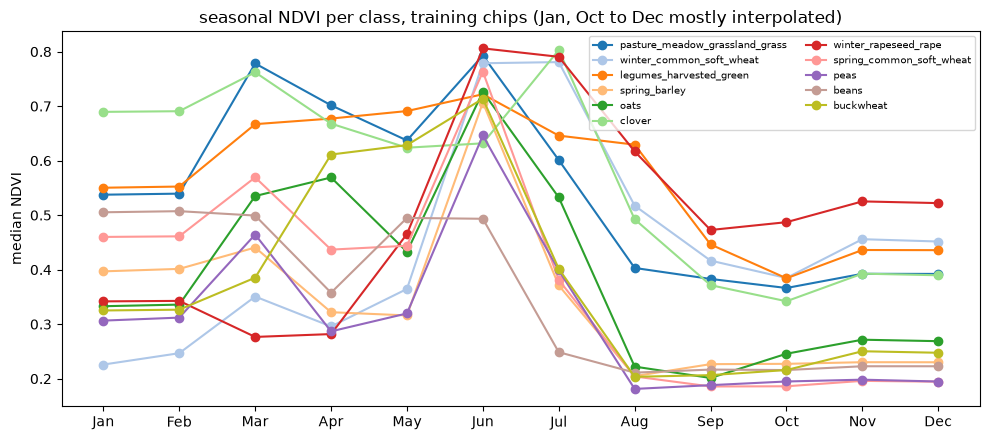

In [8]:
red, nir = dm.bands.index("RED"), dm.bands.index("NIR_BROAD")
curves = {k: [] for k in range(len(NAMES))}
for i in range(len(dm.train_dataset)):
    t = dm.train_dataset[i]
    img, msk = t["image"].numpy(), t["mask"].numpy()
    ndvi = (img[nir] - img[red]) / (img[nir] + img[red] + 1e-6)          # (months, H, W)
    for k in np.unique(msk[msk >= 0]):
        curves[k].append(ndvi[:, msk == k])
fig, ax = plt.subplots(figsize=(10, 4.5))
for k, parts in curves.items():
    if parts and sum(p.shape[1] for p in parts) > 5000:                 # classes with enough pixels
        ax.plot(MONTHS, np.median(np.concatenate(parts, 1), 1), marker="o", color=cmap(k), label=NAMES[k])
ax.set_ylabel("median NDVI"); ax.set_title("seasonal NDVI per class, training chips (Jan, Oct to Dec mostly interpolated)")
ax.legend(fontsize=7, ncol=2); plt.tight_layout()

## 4. The label budget: K polygons per class

RQ1 counts labels in **parcel polygons**, because one polygon is one annotation action, while the model predicts **pixels**. A budget of K means: draw K parcels per class from the training chips, keep the mask only on their pixels, and set every other pixel to ignore.

`draw_support` makes the draw. Its random seed depends only on (country, class, K, draw number), so every model gets exactly the same labels at a given budget. The data module applies the restriction when the mask is loaded, before augmentation, so image and mask stay aligned. Validation masks always stay dense, because the budget limits what the model trains on, not what it is scored against.

In [9]:
PCT = 5
keep, report = draw_support(ROOT, pct=PCT, draw_seed=0)
print(f"{PCT} %: {len(keep)} parcels drawn")
pd.DataFrame(report).T.sort_values("available", ascending=False).T

K=5: 94 parcels drawn


,pasture_meadow_grassland_grass,winter_common_soft_wheat,clover,oats,spring_barley,winter_rapeseed_rape,legumes_harvested_green,peas,potatoes,spring_common_soft_wheat,buckwheat,beans,alfalfa_lucerne,fresh_vegetables,rye,winter_barley,orchards_fruits,grain_maize_corn_popcorn,legumes_dried_pulses_protein_crops,spring_rapeseed_rape
available,109,73,47,43,42,35,25,25,18,17,14,12,9,9,9,7,5,5,4,0
drawn,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,4,0


/home/jovyan/.cache/pypoetry/virtualenvs/gfm4agri-7U2rqC_9-py3.11/lib/python3.11/site-packages/terratorch/datasets/generic_pixel_wise_dataset.py:131: UserWarning: expand_temporal_dimension=True assumes bands are grouped by time (all bands of one timestep are stacked together). If instead bands are grouped by channel (all timesteps of one band are stacked together), set temporal_channel_major=True.
  warnings.warn(
/home/jovyan/.cache/pypoetry/virtualenvs/gfm4agri-7U2rqC_9-py3.11/lib/python3.11/site-packages/terratorch/datasets/generic_pixel_wise_dataset.py:131: UserWarning: expand_temporal_dimension=True assumes bands are grouped by time (all bands of one timestep are stacked together). If instead bands are grouped by channel (all timesteps of one band are stacked together), set temporal_channel_major=True.
  warnings.warn(


labelled pixel fraction in training: dense 0.708, K=5 0.129


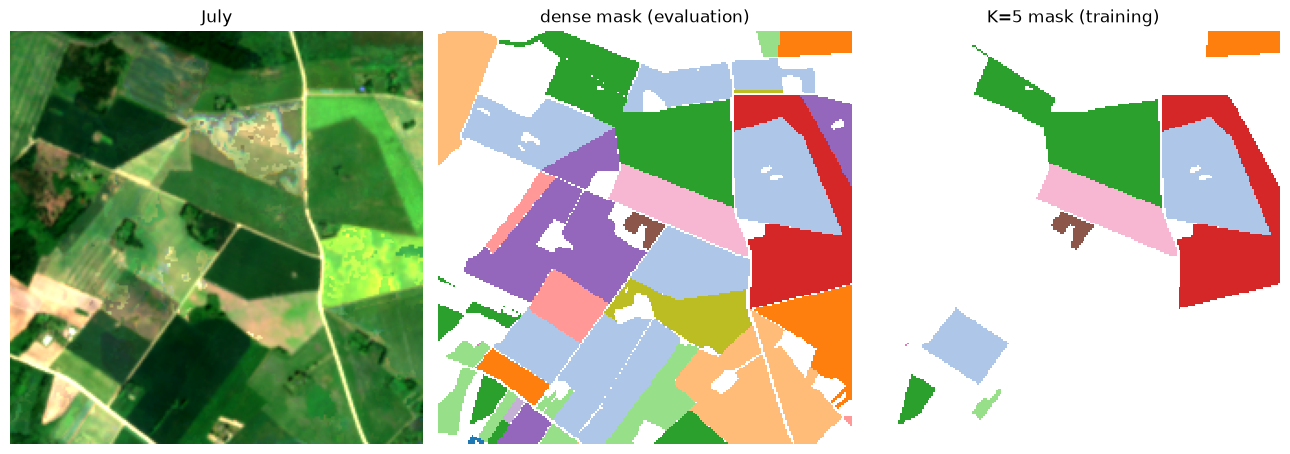

In [10]:
dm_k = EuroCropsSegDataModule(ROOT, cfg["model"]["backbone"], batch_size=1, num_workers=0,
                              augment=False, keep_parcel_ids=keep)
dm_k.setup("fit")
dense_frac = np.mean([(dm.train_dataset[i]["mask"] >= 0).float().mean() for i in range(len(dm.train_dataset))])
sparse_frac = np.mean([(dm_k.train_dataset[i]["mask"] >= 0).float().mean() for i in range(len(dm_k.train_dataset))])
print(f"labelled pixel fraction in training: dense {dense_frac:.3f}, {PCT} % {sparse_frac:.3f}")
i = int(np.argmax([(dm_k.train_dataset[j]["mask"] >= 0).sum() for j in range(len(dm_k.train_dataset))]))
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
axes[0].imshow(rgb(dm.train_dataset[i]["image"], 6)); axes[0].set_title("July"); axes[0].axis("off")
show_mask(axes[1], dm.train_dataset[i]["mask"], "dense mask (evaluation)")
show_mask(axes[2], dm_k.train_dataset[i]["mask"], f"{PCT} % mask (training)")
plt.tight_layout()

## 5. The model

A fit is **frozen encoder + trainable decoder**. The backbone registry (`src/gfm4agri/benchmark/backbones.py`) holds what is specific to each GFM, and the decoder is fixed per resolution group, so swapping in another model is one line of config. This is the TerraTorch configuration the registry produces for TerraMind:

In [11]:
spec = get_backbone(cfg["model"]["backbone"])
print("resolution group:", spec.resolution_group, "|", spec.notes)
print(json.dumps(spec.model_args(dm.bands, dm.n_timesteps), indent=1))

resolution group: token_grid | 12 layers, 384 dims; S2L2A patch embedding
{
 "backbone": "terramind_v1_small",
 "backbone_pretrained": true,
 "backbone_modalities": [
  "S2L2A"
 ],
 "backbone_bands": {
  "S2L2A": [
   "COASTAL_AEROSOL",
   "BLUE",
   "GREEN",
   "RED",
   "RED_EDGE_1",
   "RED_EDGE_2",
   "RED_EDGE_3",
   "NIR_BROAD",
   "NIR_NARROW",
   "WATER_VAPOR",
   "SWIR_1",
   "SWIR_2"
  ]
 },
 "backbone_use_temporal": true,
 "backbone_temporal_pooling": "concat",
 "backbone_temporal_n_timestamps": 12,
 "necks": [
  {
   "name": "SelectIndices",
   "indices": [
    2,
    5,
    8,
    11
   ]
  },
  {
   "name": "ReshapeTokensToImage",
   "remove_cls_token": false
  },
  {
   "name": "LearnedInterpolateToPyramidal"
  }
 ]
}


What each part does:

- **TerraMind is single-date.** The `TemporalWrapper` (`backbone_use_temporal`) runs it on each of the 12 months separately, as 12 x batch images through the same frozen weights.
- **Concat pooling** stacks the 12 monthly feature maps along the channel axis, so the decoder sees the months *in order*. Mean pooling would average the phenology away.
- **The encoder** is a ViT with 16 x 16 pixel patches, so a 224 x 224 chip becomes a **14 x 14 token grid**, one token per 160 m.
- **`SelectIndices`** takes the outputs of transformer layers 2, 5, 8 and 11. **`ReshapeTokensToImage`** turns token sequences into 14 x 14 feature maps. **`LearnedInterpolateToPyramidal`** upsamples them into a 4-level pyramid with learned transposed convolutions.
- **The UNet decoder** fuses the pyramid back to full resolution, and a 1 x 1 **head** produces 20 class logits per pixel.

The cell below pushes one batch through each stage and prints the shapes.

In [12]:
m = cfg["model"]
task = build_task(m["backbone"], num_classes=len(NAMES), class_names=NAMES, bands=dm.bands,
                  n_timesteps=dm.n_timesteps, ignore_index=dm.manifest["ignore_index"], lr=m["lr"],
                  weight_decay=m["weight_decay"], head_dropout=m["head_dropout"], loss=m["loss"])
model = task.model.to(DEVICE).eval()
xb = dm.aug(next(iter(dm.val_dataloader())))["image"].to(DEVICE)
with torch.no_grad(), torch.autocast(DEVICE, enabled=DEVICE == "cuda"):
    print("input            ", tuple(xb.shape), "(batch, bands, months, H, W)")
    feats = model.encoder(xb)
    print("encoder layers   ", [tuple(f.shape) for f in feats][:4], "... (all layers, months concatenated on the last axis)")
    neck = model.neck(feats, image_size=xb.shape[-2:])
    print("neck pyramid     ", [tuple(f.shape) for f in neck])
    dec = model.decoder([f.clone() for f in neck])
    print("decoder output   ", tuple(dec.shape))
    logits = model(xb).output
    print("logits           ", tuple(logits.shape), "(batch, classes, H, W)")

input             (4, 12, 12, 224, 224) (batch, bands, months, H, W)


encoder layers    [(4, 196, 4608), (4, 196, 4608), (4, 196, 4608), (4, 196, 4608)] ... (all layers, months concatenated on the last axis)


neck pyramid      [(4, 1152, 56, 56), (4, 2304, 28, 28), (4, 4608, 14, 14), (4, 4608, 7, 7)]


decoder output    (4, 64, 56, 56)
logits            (4, 20, 224, 224) (batch, classes, H, W)


The encoder returns every transformer layer as a sequence of 196 tokens, one per 16 x 16 patch (TerraMind emits no class token). With concat pooling each token has 12 x 384 = **4,608** channels, and the neck turns layers 2, 5, 8 and 11 into a pyramid at 56, 28, 14 and 7 pixels, still carrying 1,152 to 4,608 channels. That is why the neck and decoder are large. The parameter count shows the problem: the trainable part is about **7 times the size of the frozen encoder**. With few labels that invites overfitting, and it makes the capacity comparison across GFMs harder. A bottleneck that reduces the 4,608 channels before the pyramid is the planned next change.

In [13]:
p = count_params(task)
pd.Series({k: f"{v / 1e6:.2f} M" for k, v in p.items() if v})

encoder_total         22.46 M
neck_total            95.56 M
neck_trainable        95.56 M
decoder_total         53.79 M
decoder_trainable     53.79 M
head_total             0.00 M
head_trainable         0.00 M
trainable_total      149.35 M
all_total            171.82 M
dtype: object

## 6. Training

Training is normally done by the script, which writes the checkpoint, the logs and `results.json`:

```bash
poetry run python scripts/seg/train.py -c configs/seg/terramind_v1_large_ee_pilot.yaml
```

The cell below loads that checkpoint. If none exists, it trains here with the same configuration: cross-entropy on labelled pixels only, AdamW at lr 1e-4, 16-bit mixed precision, 40 epochs, keeping the weights with the lowest validation loss. Only the neck, decoder and head receive gradients.

In [14]:
TRAIN_HERE = not CKPT.exists()
if TRAIN_HERE:
    import lightning.pytorch as pl
    pl.seed_everything(cfg["seed"], workers=True)
    dm_train = EuroCropsSegDataModule(ROOT, m["backbone"], normalisation=d["normalisation"],
                                      batch_size=d["batch_size"], num_workers=d["num_workers"], augment=d["augment"])
    ckpt_cb = pl.callbacks.ModelCheckpoint(dirpath=CKPT.parent, monitor="val/loss", mode="min",
                                           filename="best-loss", save_weights_only=True)
    trainer = pl.Trainer(accelerator="auto", devices=1, precision=cfg["trainer"]["precision"],
                         max_epochs=cfg["trainer"]["max_epochs"], callbacks=[ckpt_cb],
                         logger=pl.loggers.CSVLogger(RUN_DIR, name="logs"), log_every_n_steps=1)
    trainer.fit(task, datamodule=dm_train)
state = torch.load(CKPT, map_location="cpu", weights_only=False)["state_dict"]
print(task.load_state_dict(state))
task = task.to(DEVICE).eval()

<All keys matched successfully>


## 7. Results

**Learning curves.** Validation macro F1 leaves chance level after about 5 epochs and is still rising at epoch 40, so the chain learns. But training loss falls much faster than validation loss, and the gap widens every epoch: the 149 M trainable parameters are starting to memorise 8 chips. That is the capacity problem from section 5 showing up in practice. With this little data the curve is a signal that the pipeline works, not an estimate of skill.

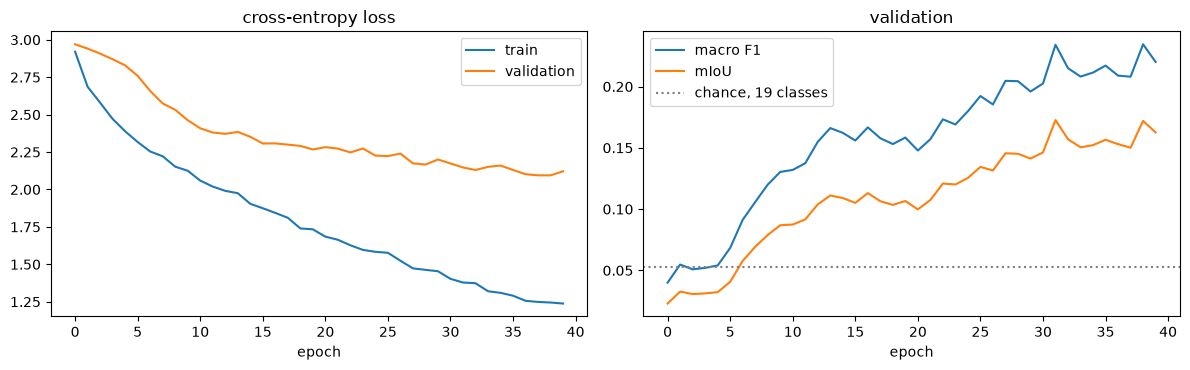

In [15]:
logs = sorted((RUN_DIR / "logs").glob("version_*/metrics.csv"))
if logs:
    h = pd.read_csv(logs[-1])
    tr = h.dropna(subset=["train/loss"]).groupby("epoch")["train/loss"].mean() if "train/loss" in h else None
    va = h.dropna(subset=["val/loss"]).set_index("epoch")
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
    if tr is not None: axes[0].plot(tr.index, tr.values, label="train")
    axes[0].plot(va.index, va["val/loss"], label="validation"); axes[0].set_title("cross-entropy loss"); axes[0].legend()
    axes[1].plot(va.index, va["val/F1_Score"], label="macro F1"); axes[1].plot(va.index, va["val/mIoU"], label="mIoU")
    axes[1].axhline(1 / 19, ls=":", c="grey", label="chance, 19 classes"); axes[1].set_title("validation"); axes[1].legend()
    for a in axes: a.set_xlabel("epoch")
    plt.tight_layout()
else:
    print("no CSV logs found for", RUN_DIR)

**Prediction maps.** For each validation chip: July true colour, the dense reference, the prediction over the whole chip, and correct (green) against wrong (red) on labelled pixels.

Note the **blobby prediction boundaries**. TerraMind sees the chip as 14 x 14 tokens of 160 m, and the decoder has to invent the 10 m detail. Parcel edges are therefore not respected. This is the resolution-group effect CLAUDE.md declares as an experimental factor, and it is why token-grid models are compared among themselves and not directly against 10 m embedding models.

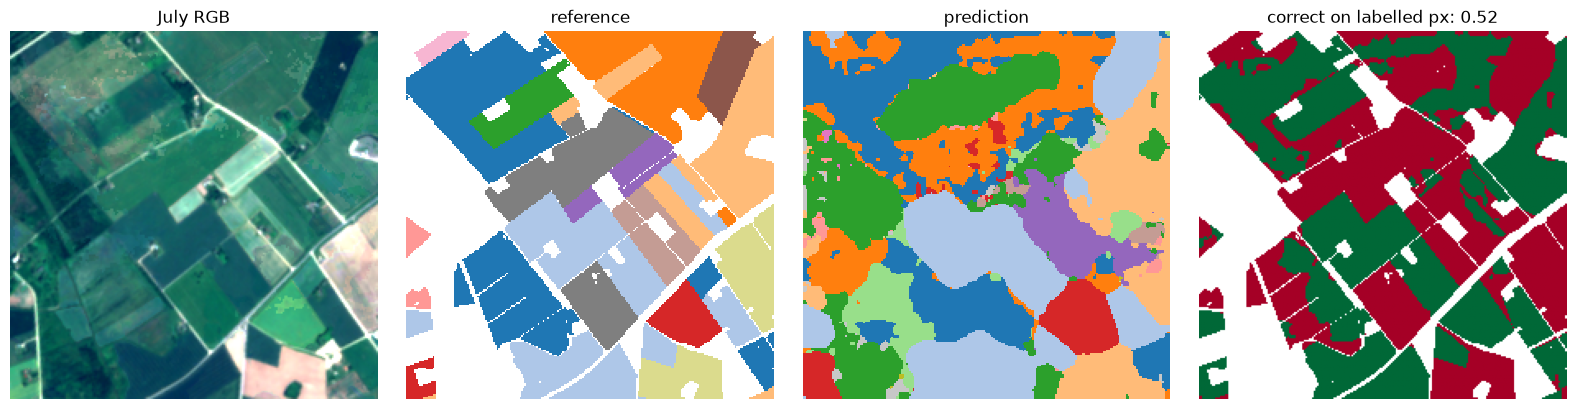

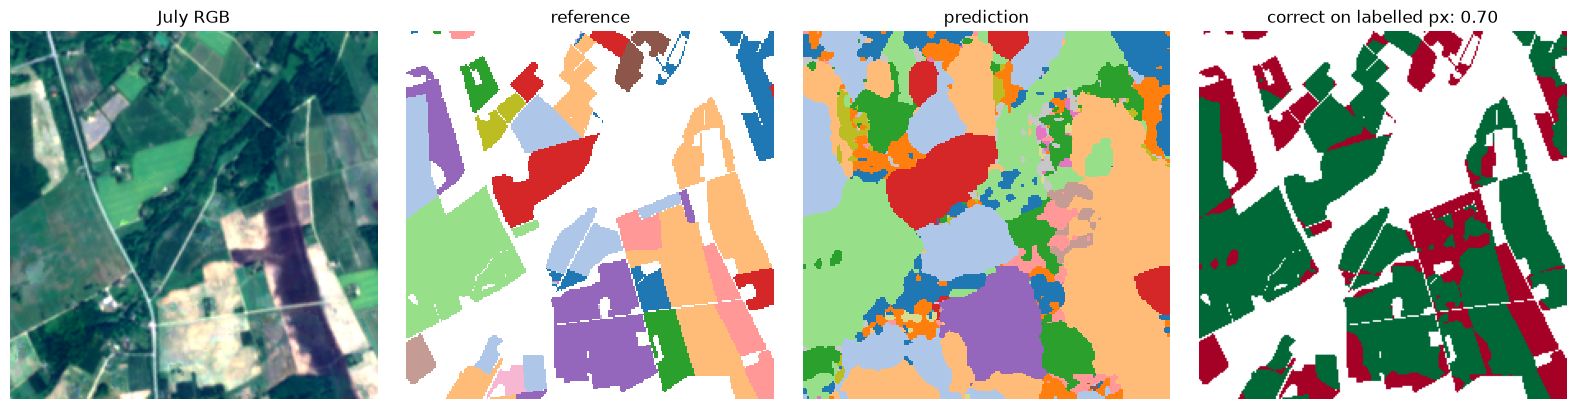

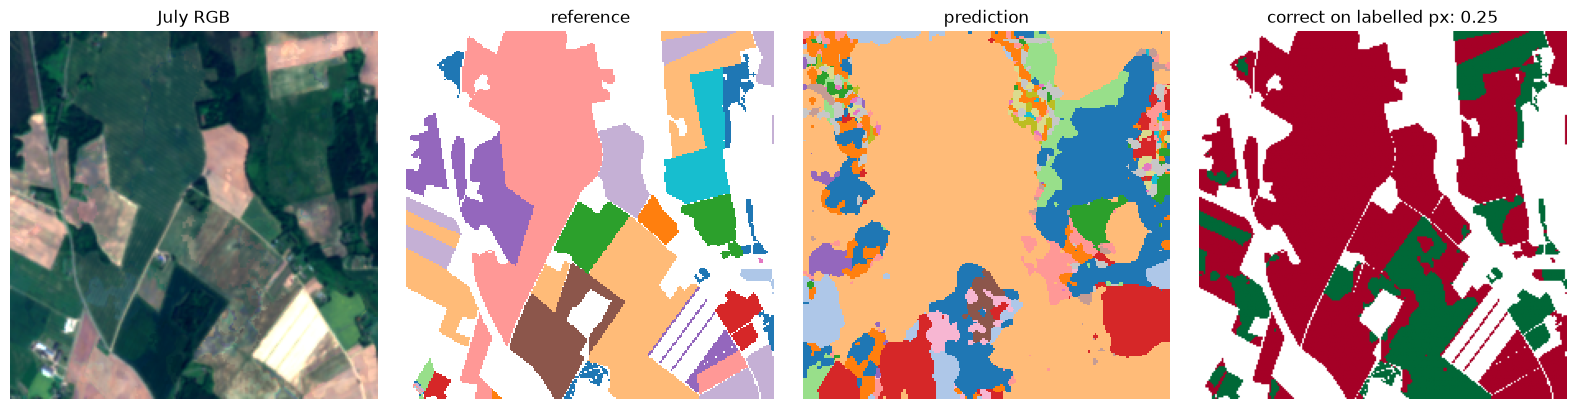

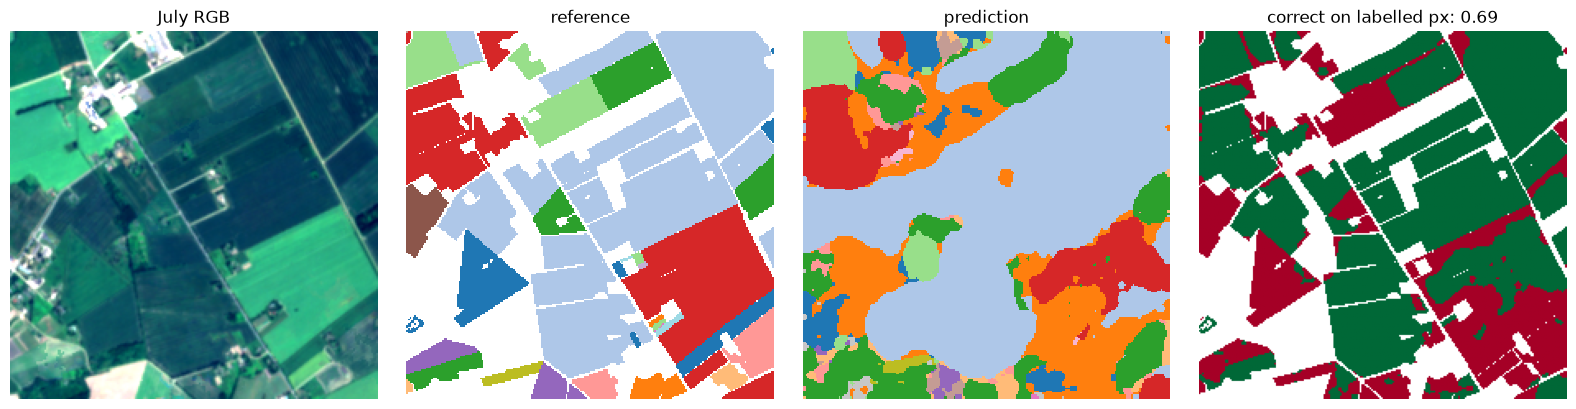

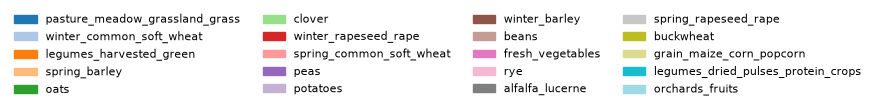

In [16]:
preds, masks, images = [], [], []
with torch.no_grad():
    for b in dm.val_dataloader():
        xv = dm.aug(b)["image"].to(DEVICE)
        preds.append(task(xv).output.argmax(1).cpu()); masks.append(b["mask"]); images.append(b["image"])
preds, masks, images = torch.cat(preds), torch.cat(masks), torch.cat(images)
for i in range(len(preds)):
    lab = masks[i] >= 0
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(rgb(images[i], 6)); axes[0].set_title("July RGB"); axes[0].axis("off")
    show_mask(axes[1], masks[i], "reference")
    show_mask(axes[2], preds[i], "prediction")
    axes[3].imshow(np.ma.masked_where(~lab.numpy(), (preds[i] == masks[i]).numpy()), cmap="RdYlGn", vmin=0, vmax=1)
    axes[3].set_title(f"correct on labelled px: {(preds[i][lab] == masks[i][lab]).float().mean():.2f}"); axes[3].axis("off")
    plt.tight_layout()
legend()

**Per-class scores.** Macro F1 averages over all 20 classes, including those with few or no validation pixels. The bar chart orders classes by validation pixel count, which explains most of the pattern: well-represented classes with a distinctive season (winter wheat, winter rapeseed, clover) are learned, and rare classes score zero. `spring_rapeseed_rape` has no parcels in Estonia at all, so it can never score. Phase 1 will report Macro-F1 over the classes present, with bootstrap confidence intervals.

pixel accuracy 0.537 | macro F1 all 20 classes 0.235 | macro F1 over the 19 classes present 0.247


,class,val pixels,IoU,F1
1,winter_common_soft_wheat,27551,0.747,0.855
3,spring_barley,18970,0.342,0.510
0,pasture_meadow_grassland_grass,13380,0.335,0.502
7,spring_common_soft_wheat,13031,0.018,0.035
6,winter_rapeseed_rape,12910,0.678,0.808
8,peas,9639,0.261,0.413
4,oats,7050,0.313,0.477
5,clover,6575,0.507,0.673
10,winter_barley,4801,0.045,0.085
2,legumes_harvested_green,4585,0.183,0.310


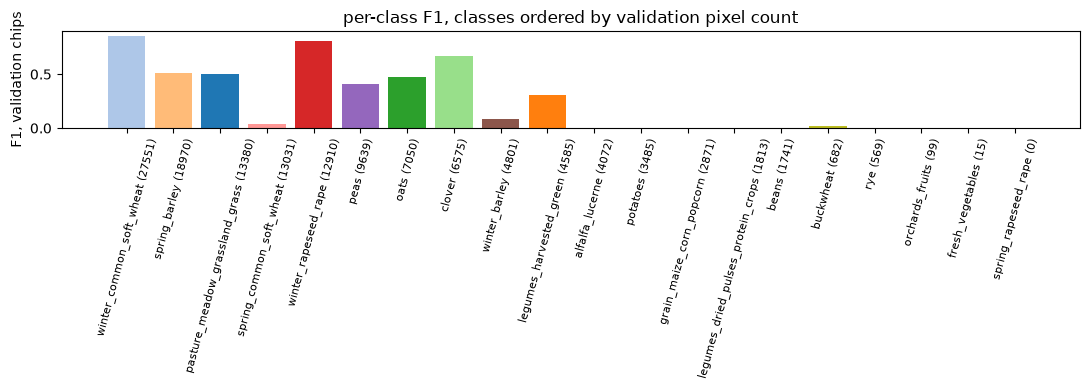

In [17]:
pv = preds[masks >= 0].numpy(); rv = masks[masks >= 0].numpy()
rows = []
for k, n in enumerate(NAMES):
    tp = np.sum((pv == k) & (rv == k)); fp = np.sum((pv == k) & (rv != k)); fn = np.sum((pv != k) & (rv == k))
    rows.append({"class": n, "val pixels": int((rv == k).sum()), "IoU": tp / max(tp + fp + fn, 1),
                 "F1": 2 * tp / max(2 * tp + fp + fn, 1)})
per_class = pd.DataFrame(rows).sort_values("val pixels", ascending=False)
present = per_class["val pixels"] > 0
print(f"pixel accuracy {np.mean(pv == rv):.3f} | macro F1 all 20 classes {per_class['F1'].mean():.3f} "
      f"| macro F1 over the {present.sum()} classes present {per_class.loc[present, 'F1'].mean():.3f}")
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(range(len(per_class)), per_class["F1"], color=[cmap(NAMES.index(n)) for n in per_class["class"]])
ax.set_xticks(range(len(per_class)), [f"{c} ({v})" for c, v in zip(per_class["class"], per_class["val pixels"])],
              rotation=75, fontsize=8)
ax.set_ylabel("F1, validation chips"); ax.set_title("per-class F1, classes ordered by validation pixel count")
plt.tight_layout()
per_class.round(3)

## 8. What this establishes, and what comes next

**Established.** The chips load through TerraTorch unchanged. The 12-month stack reaches a frozen TerraMind through the temporal wrapper. The decoder trains on labelled pixels only. The K-polygon budget works end to end. Every run from the script records its configuration, budget, country, split protocol and parameter counts in `results.json`.

**Before the numbers mean anything:**

1. **Decoder capacity.** Add a channel bottleneck after the temporal concat, so the trainable part is not about 7 times the encoder and can be matched across GFMs.
2. **Feature caching.** The encoder is frozen, so its features per chip, and per D4 variant, can be computed once and reused for every K and draw.
3. **Proper splits.** The full export with spatial blocks, buffers and held-out test blocks, instead of this pilot.
4. **Normalisation check.** One run with `normalisation: chips` against the TerraMind statistics.
5. **Next GFM.** THOR as a second registry entry in the token-grid group.

To try variations from the command line:

```bash
poetry run python scripts/seg/train.py -c configs/seg/terramind_v1_large_ee_pilot.yaml --set label_budget.mode=pct label_budget.pct=5
poetry run python scripts/seg/train.py -c configs/seg/terramind_v1_large_ee_pilot.yaml --set data.normalisation=chips run_name=terramind_chipnorm
poetry run python scripts/seg/train.py -c configs/seg/terramind_v1_large_ee_pilot.yaml --set model.backbone=terramind_v1_base run_name=terramind_base
```